# Vizualización de Mapa de Activación de Clase

Un Mapa de *Activacion de Clase* (CAM) es una tecnica de interpretabilidad que permite determinar la importancia de cada sector de una imagen respecto a una clase en consideración. 

La tecnica toma el *feature map* saliente de una capa convolucional y respecto a la imagen de entrada pondera cada canal del *feature map* (recordemos que cada canal filtra un patron distinto) por el gradiente de la clase respecto al canal.

Para ejemplificar se va a construir una visualizacion CAM con el modelo VGG16.

In [2]:
from keras.applications.vgg16 import VGG16

model = VGG16(weights='imagenet')
model.summary()

I0000 00:00:1753838019.919102  591744 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11398 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1
2025-07-29 22:13:42.032603: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Preparar una imagen de entrada para sobre la que hacer la prueba.

![Imagen elefante y su cria](./images/creative_commons_elephant.png)

In [3]:
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input, decode_predictions
import numpy as np
import os

img_path = os.path.expanduser('~/libros/dlwp/images/creative_commons_elephant.png')
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img) # (224,224,3)
x = np.expand_dims(x, axis=0) # (1, 224,224,3)
x = preprocess_input(x)

Prediccion al ejecutar VGG16 con la imagen:

In [4]:
preds = model.predict(x)
print('Predicted: ', decode_predictions(preds, top=3)[0])
print('Index of max class: ', np.argmax(preds[0]))

I0000 00:00:1753838108.918435  591864 service.cc:152] XLA service 0x7fd0b4003da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753838108.918469  591864 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-07-29 22:15:08.928335: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753838109.018131  591864 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-29 22:15:09.201224: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.39 = (f32[1,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,3,224,224]{3,2,1,0} %bitcast.513, f32[64,3,3,3]{3,2,1,0} %bitcast.520, f32[64]{0} %bitcast.522), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted:  [('n02504458', 'African_elephant', np.float32(0.86433625)), ('n01871265', 'tusker', np.float32(0.12543601)), ('n02504013', 'Indian_elephant', np.float32(0.010065498))]
Index of max class:  386


I0000 00:00:1753838110.267032  591864 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Proceso *Gradiente de Mapa de Activacion de Clase* (Grad-CAM):

In [ ]:
from tensorflow.keras import backend as K

# Tensorflow 1.x
african_elephant_output = model.output[:, 386]
last_conv_layer = model.get_layer('block5_conv3') # Ultima capa convolucional en VGG16
grads = K.gradients(african_elephant_output, last_conv_layer.output)[0] # Gradiente de la salida del conv respecto a la clase
pooled_grads = K.mean(grads, axis=(0, 1, 2)) # 512 (1 entrada por cada kernel)
iterate = K.function([model.input], [pooled_grads, last_conv_layer.output[0]]) # Dada una entrada, calcula pool de gradientes y probabilidades de salida

pooled_grads_value, conv_layer_output_value = iterate([x]) # Valores para la imagen de entrada
for i in range(512):
    conv_layer_output_value[:, :, i] *= pooled_grads_value[i]   # Cada canal * importancia para clase 386 (elefante africano)
heatmap = np.mean(conv_layer_output_value, axis=-1) # Promedia importancia en todos los canales

<KerasTensor shape=(None,), dtype=float32, sparse=False, ragged=False, name=keras_tensor_47>


In [6]:
# Tensorflow 2.x
import tensorflow as tf

last_conv_layer = model.get_layer('block5_conv3') # Ultima capa convolucional en VGG16
headmap_model = tf.keras.Model(inputs=model.inputs, outputs=[last_conv_layer.output, model.output])

with tf.GradientTape() as tape:
    conv_outputs, predictions = headmap_model(x)
    class_idx = tf.argmax(predictions[0])
    class_output = predictions[:, class_idx]

grads = tape.gradient(class_output, conv_outputs)   # Gradiente de la salida del conv respecto a la clase
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))    # 512 (1 entrada por cada kernel)

conv_outputs = conv_outputs[0]  # Quitamos el batch -> queda (H, W, 512)
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis] # Cada pixel queda representado por un valor que resulta de la sumatoria del valor del pixel en cada canal por la importancia del canal para la clase objetivo -> (H,W,1)
heatmap = tf.squeeze(heatmap)   # (H, W)
heatmap = heatmap / tf.constant(512.0)
heatmap = heatmap.numpy()

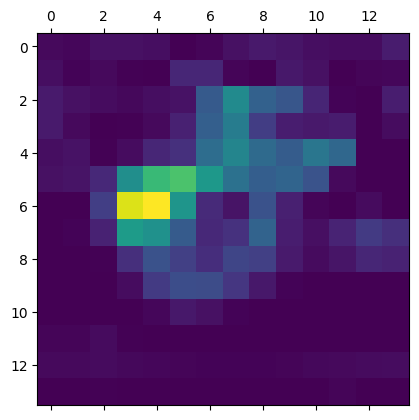

In [11]:
import matplotlib.pyplot as plt

heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
plt.matshow(heatmap)

Redimencionar y superponer con la imagen original:

In [13]:
import cv2

save_img_path = os.path.expanduser('~/libros/dlwp/images/creative_commons_elephant_cam.png')
img = cv2.imread(img_path)
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap) # RGB
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = heatmap * 0.4 + img  # Intensidad del headmap
cv2.imwrite(save_img_path, superimposed_img)

[ WARN:0@0.109] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


True

![Imagen elefante y su cria](./images/creative_commons_elephant_cam.png)